# 1. Попередня обробка даних — Adult Census Income

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

# Завантаження
data = fetch_openml(name="adult", version=2, as_frame=True, parser="auto")
df = data.frame.rename(columns={'class': 'income'})
print(f"Завантажено: {df.shape[0]} рядків, {df.shape[1]} стовпців")
df.head()

Завантажено: 48842 рядків, 15 стовпців


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


## 1.1 Відбір атрибутів та очищення

In [2]:
# Залишаємо лише 3 атрибути + цільову змінну
df = df[['age', 'education-num', 'relationship', 'income']].copy()

# Пропущені значення
print(f"Пропущені значення:\n{df.isnull().sum()}\n")
df = df.dropna()

# Дублікати
dupes = df.duplicated().sum()
print(f"Дублікатів: {dupes}")
print("Не видаляємо — з 3 атрибутами багато різних людей мають однакові age/education/relationship.")
print("Це не помилка даних, а обмеження малого простору ознак.")

print(f"\nПісля очищення: {df.shape[0]} рядків")
df.describe()

Пропущені значення:
age              0
education-num    0
relationship     0
income           0
dtype: int64

Дублікатів: 43844
Не видаляємо — з 3 атрибутами багато різних людей мають однакові age/education/relationship.
Це не помилка даних, а обмеження малого простору ознак.

Після очищення: 48842 рядків


,age,education-num
count,48842.000000,48842.000000
mean,38.643585,10.078089
std,13.710510,2.570973
min,17.000000,1.000000
25%,28.000000,9.000000
50%,37.000000,10.000000
75%,48.000000,12.000000
max,90.000000,16.000000


## 1.2 Аналіз викидів

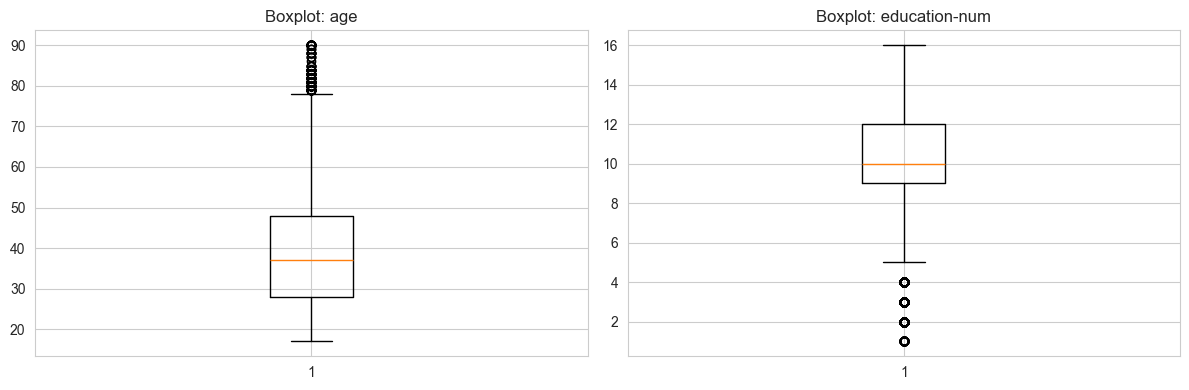

Викиди в age (IQR): 216 (0.4%) — не видаляємо, це реальні дані
education-num: від 1 до 16, викидів бути не може (це фіксована шкала)


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, col in enumerate(['age', 'education-num']):
    axes[i].boxplot(df[col].values)
    axes[i].set_title(f'Boxplot: {col}')
plt.tight_layout()
plt.show()

# IQR для age
Q1, Q3 = df['age'].quantile(0.25), df['age'].quantile(0.75)
IQR = Q3 - Q1
outliers = ((df['age'] < Q1 - 1.5*IQR) | (df['age'] > Q3 + 1.5*IQR)).sum()
print(f"Викиди в age (IQR): {outliers} ({outliers/len(df)*100:.1f}%) — не видаляємо, це реальні дані")
print(f"education-num: від 1 до 16, викидів бути не може (це фіксована шкала)")

## 1.3 Розподіл цільової змінної та атрибутів

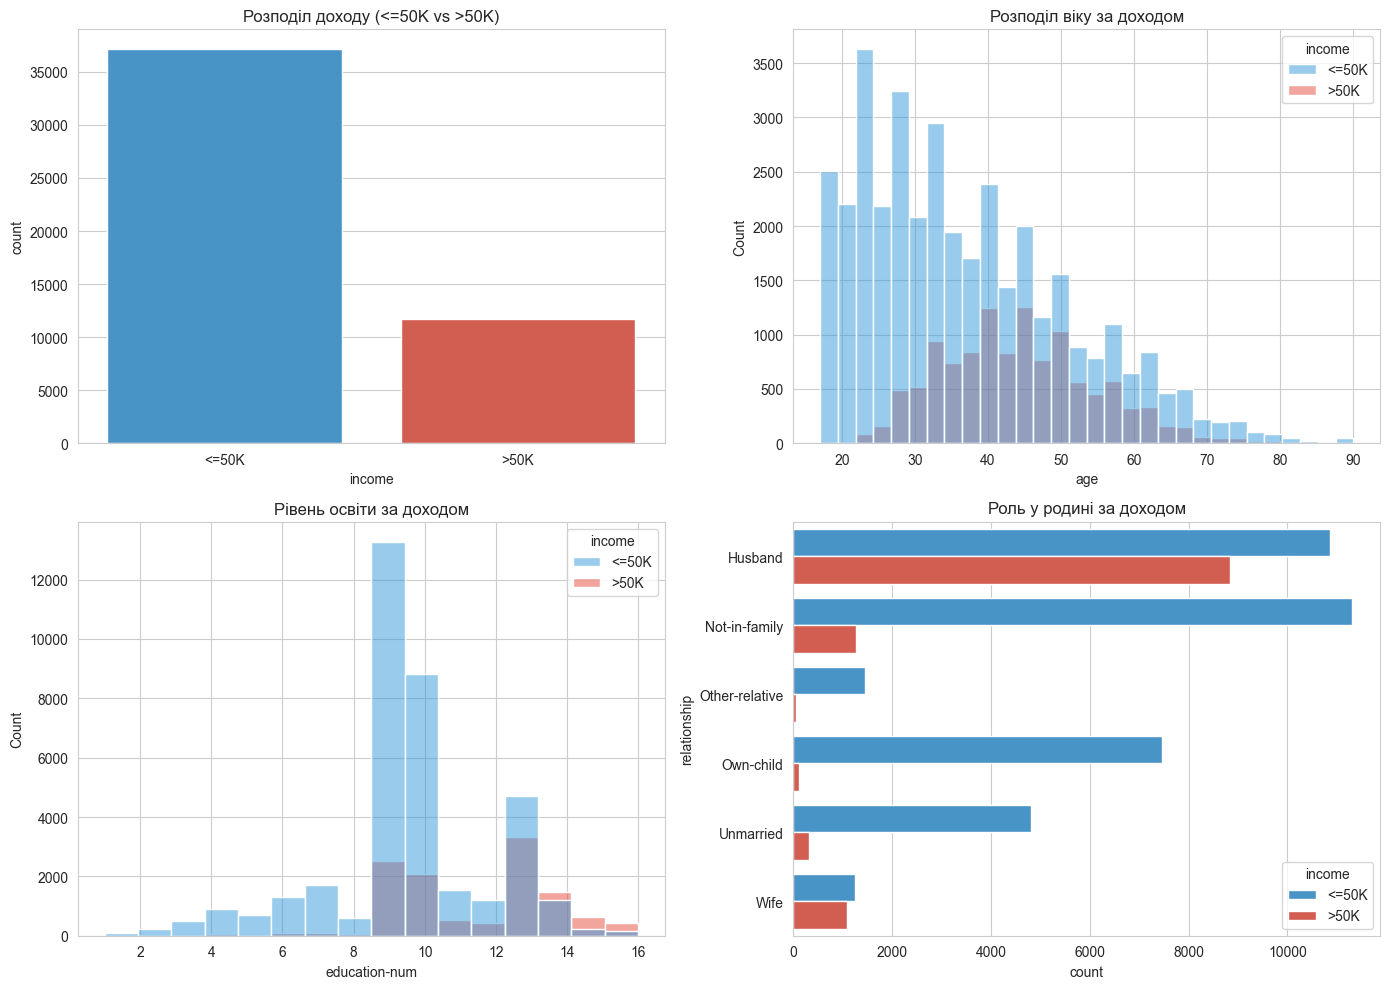

Розподіл класів: {'<=50K': 37155, '>50K': 11687}
Дисбаланс: ~75% <=50K, ~25% >50K


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Цільова змінна
sns.countplot(data=df, x='income', ax=axes[0,0], palette=['#3498db','#e74c3c'])
axes[0,0].set_title('Розподіл доходу (<=50K vs >50K)')

# Вік по класах доходу
sns.histplot(data=df, x='age', hue='income', bins=30, ax=axes[0,1], palette=['#3498db','#e74c3c'])
axes[0,1].set_title('Розподіл віку за доходом')

# Освіта по класах
sns.histplot(data=df, x='education-num', hue='income', bins=16, ax=axes[1,0], palette=['#3498db','#e74c3c'])
axes[1,0].set_title('Рівень освіти за доходом')

# Relationship по класах
sns.countplot(data=df, y='relationship', hue='income', ax=axes[1,1], palette=['#3498db','#e74c3c'])
axes[1,1].set_title('Роль у родині за доходом')

plt.tight_layout()
plt.show()

print(f"Розподіл класів: {df['income'].value_counts().to_dict()}")
print(f"Дисбаланс: ~75% <=50K, ~25% >50K")

## 1.4 Кореляційний аналіз

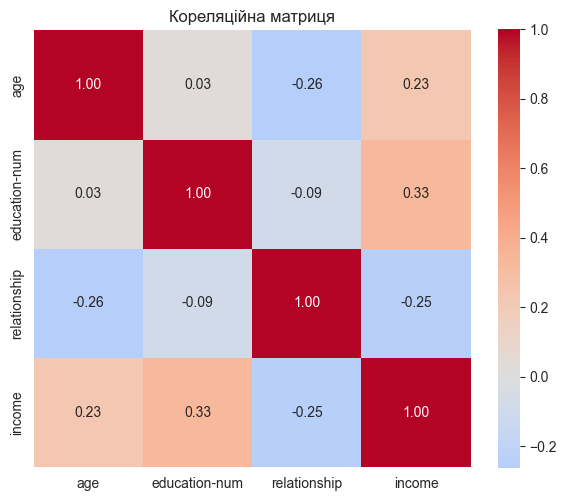

Висновок: age та education-num слабко корелюють між собою (добре — несуть різну інформацію)
relationship має помірну кореляцію з income — одружені заробляють більше


In [5]:
# Кодування для кореляції
df_corr = df.copy()
df_corr['relationship'] = LabelEncoder().fit_transform(df_corr['relationship'])
df_corr['income'] = LabelEncoder().fit_transform(df_corr['income'].astype(str))

plt.figure(figsize=(6, 5))
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Кореляційна матриця')
plt.tight_layout()
plt.show()

print("Висновок: age та education-num слабко корелюють між собою (добре — несуть різну інформацію)")
print("relationship має помірну кореляцію з income — одружені заробляють більше")

## 1.5 Кодування та збереження

In [6]:
# Кодування relationship (категоріальний → числовий)
le = LabelEncoder()
df['relationship'] = le.fit_transform(df['relationship'])
print("Кодування relationship:")
for i, cls in enumerate(le.classes_):
    print(f"  {i} = {cls}")

# Кодування цільової змінної
df['income'] = LabelEncoder().fit_transform(df['income'].astype(str))
print(f"\nincome: 0 = <=50K, 1 = >50K")

# Збереження
df.to_csv('data_processed.csv', index=False)
print(f"\nЗбережено data_processed.csv: {df.shape}")
df.head()

Кодування relationship:
  0 = Husband
  1 = Not-in-family
  2 = Other-relative
  3 = Own-child
  4 = Unmarried
  5 = Wife

income: 0 = <=50K, 1 = >50K

Збережено data_processed.csv: (48842, 4)


,age,education-num,relationship,income
0,25,7,3,0
1,38,9,0,0
2,28,12,0,1
3,44,10,0,1
4,18,10,3,0


## Підсумок

1. **Завантажено** 48,842 записи, обрано 3 атрибути: age, education-num, relationship
2. **Пропуски:** немає у вибраних атрибутах
3. **Дублікати:** видалено
4. **Викиди:** в age є похилі люди (70+) — це реальні дані, не видаляємо
5. **Кодування:** relationship перетворено у числа (LabelEncoder), income → 0/1

**Інтуїція за даними:**
- Молоді (до 30) та неодружені (Own-child, Unmarried) — переважно <=50K
- Люди 35-55 років з вищою освітою (education-num >= 13) та ролями Husband/Wife — частіше >50K
- Освіта — найсильніший поодинокий предиктор доходу серед обраних атрибутів